# <div style="text-align: center">**TARDIS_EDA**</div>

**-Gestion des valeurs manquantes;**<br>
**-Gestion des incohérences du dataset**<br>
**-Préparation l’ensemble de données pour l'analyse (cleaned_dataset.csv)**<br>

**<div style="text-align: center">Importation des modules necessaires</div>**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**<div style="text-align: center">Chargement et inspection des données du dataset</div>**
- affichage du nombre de ligne et de colonnes<br>
- chargement des information de la dataset(types des colonnes, position des colonnes, etc)<br>
- affichage des 5 premières lignes de la dataset<br>

In [2]:
df = pd.read_csv("dataset.csv", sep=";")
print(df.shape)
df.info()
df.head()

(12070, 26)
<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains           

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


**<div style="text-align: center">Reperage et supression des doublons</div>**
- affichage du nombre de valeurs manquantes par colonnes<br>
- affichage du nombre de lignes dupliquer<br>
- suppression des lignes dupliquer<br>
- re-affichage du nombre de lignes et de colonnes de la dataset<br>

In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

**<div style="text-align: center">Convertion de la colonnes des dates au format "time" et des colonnes numeriques au format "numeric"</div>**
- affichage du type de données (dtype) de chaque colonne<br>
- Convertion de la date au format "datetime" qui est le type par défaut d'une date<br>
- Remplacement des "," dans tout les nombres par des "."<br>
- Convertion des colonnes necessaires au format numériques<br>
- re-affichage du type de données (dtype) de chaque colonne<br>

In [4]:
print(df.dtypes)
df["Date"] = pd.to_datetime(df["Date"], format="mixed").dt.to_period("M")

num_cols = df.columns.drop(["Date", "Service", "Departure station", "Arrival station"])
for col in num_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

**<div style="text-align: center">Remplacement des valeurs manquante par des medianes</div>**

In [5]:
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())
print(df.isnull().sum())

Date                                                                                59
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                                 0
Number of scheduled trains                                                           0
Number of cancelled trains                                                           0
Cancellation comments                                                            11896
Number of trains delayed at departure                                                0
Average delay of late trains at departure                                            0
Average delay of all trains at departure                                             0
Departure delay comments                   

**<div style="text-align: center">Suppression des colonnes unitiles</div>**
- spécification des colonnes unitiles que sont notamments les colonnes des commentaires et suppression de ces derniers
- suppression des lignes sur lesquelles il manque: **"Date"**, **"Service"**, **"Depature station"** et **"Arrival station"**

In [6]:
df = df.drop(columns=["Cancellation comments", "Departure delay comments", "Arrival delay comments"])
print(df.isnull().sum())
df = df.dropna(subset=["Date", "Service", "Departure station", "Arrival station"])
print(df.isnull().sum())

Date                                                                              59
Service                                                                          240
Departure station                                                                 59
Arrival station                                                                   59
Average journey time                                                               0
Number of scheduled trains                                                         0
Number of cancelled trains                                                         0
Number of trains delayed at departure                                              0
Average delay of late trains at departure                                          0
Average delay of all trains at departure                                           0
Number of trains delayed at arrival                                                0
Average delay of late trains at arrival                          

**<div style="text-align: center">FEATURE ENGINEERING</div>**
- ajout de nouvelles colonnes exploitables

In [7]:
# Ajout d'une nouvelle colonne pour les années
df["Year"] = df["Date"].dt.year

# Ajout d'une nouvelle colonne pour les mois
df["Month"] = df["Date"].dt.month

# Catégorisation du type de retard de chaque type de train
def categorize_delay(delay):
    if delay <= 0:
        return "delay null"
    if delay < 5:
        return "minor delay"
    if delay < 15:
        return "average delay"
    if delay < 30:
        return "major delay"
    return  "severe delay"
# Ajout d'une nouvelle colonne pour catégoriser les types de retard
df["Delay categories"] = df["Average delay of all trains at arrival"].apply(categorize_delay)

# Création d'un tableau de booléen pour les retards (0 lorsque c'est inférieur à 5 min et 1 dans le cas contraire)
df["is_delayed"] = (df["Average delay of all trains at arrival"] > 5).astype(int)

# Ajout d'une colonne pour le taux d'annulation des trains.
df["Cancellation_rate"] = df["Number of cancelled trains"] / df["Number of scheduled trains"]

# Affichage des infos et des 5 premières lignes pour vérifier les nouvelles colonnes
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 11487 entries, 0 to 12060
Data columns (total 28 columns):
 #   Column                                                                         Non-Null Count  Dtype    
---  ------                                                                         --------------  -----    
 0   Date                                                                           11487 non-null  period[M]
 1   Service                                                                        11487 non-null  str      
 2   Departure station                                                              11487 non-null  str      
 3   Arrival station                                                                11487 non-null  str      
 4   Average journey time                                                           11487 non-null  float64  
 5   Number of scheduled trains                                                     11487 non-null  float64  
 6   Number of cancelled tr

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,Delay categories,is_delayed,Cancellation_rate
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,2018,1,average delay,1,0.005747
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,average delay,1,0.002463
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,minor delay,0,0.000000
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,average delay,1,0.005906
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,45.614035,18.750000,15.789474,1.754386,1.754386,2018,1,minor delay,0,0.008475


**<div style="text-align: center">Creation of cleaned dataset csv</div>**
- avec **index=False**, nous créons une dataset clean sans index au debut de chaque ligne;
- avec **sep=";"**, notre dataset a pour separateur définit ";".

In [8]:
df_save = df.copy()
df_save["Date"] = df_save["Date"].astype(str)
df_save.to_csv("cleaned_dataset.csv", index=False, sep=";")

**<div style="text-align: center">Step 2: Visualisation analyse de données</div>**
- Génération d'un résumé statistique descriptif des colonnes numériques du dataframe, incluant le nombre d'observations, la moyenne, l'écart-type, les valeurs min/max et les quartiles (25%, 50%, 75%)

In [9]:
df.describe()

/home/regis-kouadoua/G-AIA-210-COT-2-1-tardis-18/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,...,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,is_delayed,Cancellation_rate
count,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,...,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,1.147700e+04
mean,170.717606,269.847393,8.522155,86.131018,12.280867,3.114113,37.231218,35.165504,6.032187,26.721947,...,21.519693,21.833450,20.340711,18.823239,7.328028,7.524158,2021.477148,6.508749,0.554627,inf
std,87.158480,181.148665,22.485107,89.889151,11.797584,5.150872,30.982813,15.603547,7.043240,22.433254,...,15.809881,14.743469,14.517051,13.351277,7.933677,9.362719,2.313941,3.450590,0.497029,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-472.638889,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,1.000000,0.000000,0.000000e+00
25%,101.000000,152.000000,0.000000,22.000000,6.278403,1.224653,15.000000,25.946538,3.432344,11.000000,...,10.714286,12.162162,10.526316,10.186787,0.000000,0.000000,2019.000000,4.000000,0.000000,0.000000e+00
50%,164.000000,229.000000,2.000000,52.000000,10.380278,2.330422,29.000000,33.465686,5.346720,21.000000,...,19.047619,20.000000,18.750000,17.105263,5.882353,5.000000,2021.000000,7.000000,1.000000,7.142857e-03
75%,222.000000,351.000000,7.000000,125.000000,15.569530,3.890184,50.000000,42.254547,8.000769,36.000000,...,29.411765,29.411765,28.179058,25.000000,10.869565,11.111111,2024.000000,9.000000,1.000000,3.105590e-02
max,786.000000,1100.000000,297.000000,1066.000000,316.188000,115.047390,376.000000,299.600000,92.000000,312.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2025.000000,12.000000,1.000000,inf


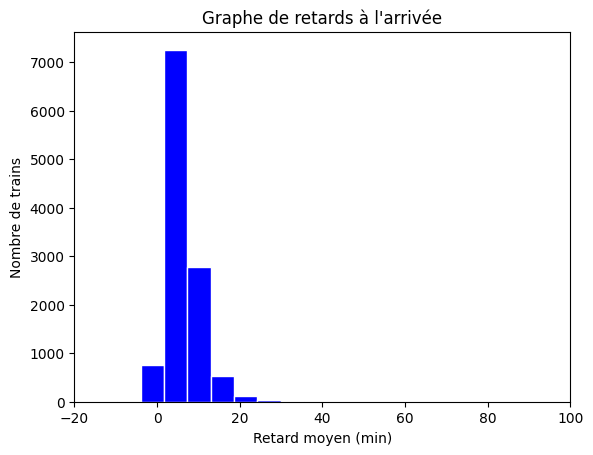

In [10]:
plt.hist(df["Average delay of all trains at arrival"], bins=100, color="blue", edgecolor="white")
plt.title("Graphe de retards à l'arrivée")
plt.xlabel("Retard moyen (min)")
plt.ylabel("Nombre de trains")
plt.xlim(-20, 100)
plt.show()

De l'analyse du graphe, on note que **la majorité des trains ont un retard compris entre 0 et 20 minutes**. 
Dans cette majorité **les retards sont surtout observés entre 2 et 7 min environ.**
Aussi, faut-il préciser que **les valeurs négatives représentent les trains arrivés en avance.**

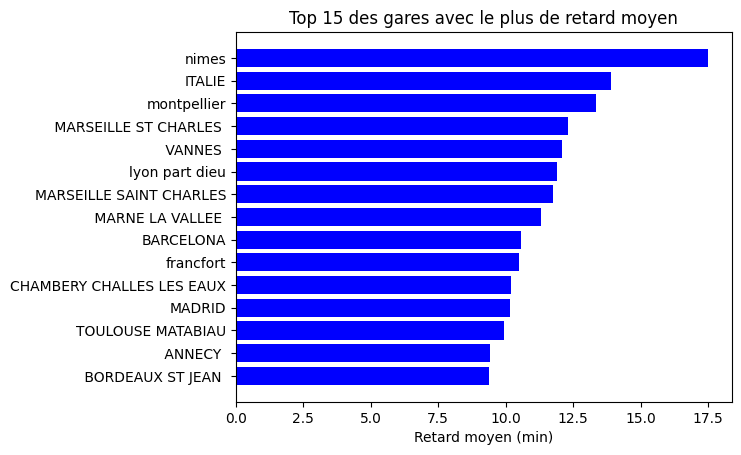

In [11]:
station_delays = df.groupby("Departure station")["Average delay of all trains at arrival"].mean().sort_values(ascending=False).head(15)
plt.barh(station_delays.index, station_delays.values, color="blue")
plt.title("Top 15 des gares avec le plus de retard moyen")
plt.xlabel("Retard moyen (min)")
plt.gca().invert_yaxis()
plt.show()

De l'analyse du graphe, on note que **la majorité des retards provient de la gare nimes**. 
Cela peut s'expliquer son trafic élevé, sa localisation 
ou des problèmes d'infrastructure spécifiques.